# RoadSafe India — Exploratory Data Analysis

## Objective

The purpose of this notebook is to explore the cleaned State/UT-level
road-accident dataset and identify important patterns, trends and
differences across India.

## Questions

1. How do total reported road accidents change from 2020 to 2024?
2. Which States/UTs report the highest accident counts?
3. Which States/UTs report the lowest accident counts?
4. Which States/UTs experienced the largest changes between 2023 and 2024?
5. How do State/UT rankings change across the study period?

In [26]:
import pandas as pd
import matplotlib.pyplot as plt


In [27]:
# Load the cleaned dataset
df = pd.read_csv(
    "../data/processed/state_wise_road_accidents_2020_2024_cleaned.csv"
)

print("Cleaned dataset loaded successfully.")
print(f"Shape: {df.shape}")

Cleaned dataset loaded successfully.
Shape: (39, 14)


In [28]:
# RoadSafe India — National Accident Trend

# Columns containing yearly accident counts
year_columns = [
    "2020_accidents",
    "2021_accidents",
    "2022_accidents",
    "2023_accidents",
    "2024_accidents"
]

# Calculate the total accidents across all States/UTs for each year
national_accidents = df[year_columns].sum()

print("Total reported road accidents by year:")
display(national_accidents)

Total reported road accidents by year:


2020_accidents    744362.0
2021_accidents    824864.0
2022_accidents    922624.0
2023_accidents    961166.0
2024_accidents    975414.0
dtype: float64

In [29]:
# Convert the yearly totals into a tidy DataFrame

national_accidents_df = national_accidents.reset_index()

national_accidents_df.columns = [
    "year",
    "accidents"
]

# Convert the year column from text such as "2020_accidents" to integer years
national_accidents_df["year"] = (
    national_accidents_df["year"]
    .str.replace("_accidents", "", regex=False)
    .astype(int)
)

display(national_accidents_df)

,year,accidents
0,2020,744362.0
1,2021,824864.0
2,2022,922624.0
3,2023,961166.0
4,2024,975414.0


In [30]:
# Calculate year-over-year percentage change

national_accidents_df["year_over_year_change_percent"] = (
    national_accidents_df["accidents"]
    .pct_change()
    * 100
)

display(national_accidents_df)

,year,accidents,year_over_year_change_percent
0,2020,744362.0,NaN
1,2021,824864.0,10.814899
2,2022,922624.0,11.851651
3,2023,961166.0,4.177433
4,2024,975414.0,1.482366


In [31]:
# Calculate overall percentage change from 2020 to 2024

accidents_2020 = national_accidents_df.loc[
    national_accidents_df["year"] == 2020,
    "accidents"
].iloc[0]

accidents_2024 = national_accidents_df.loc[
    national_accidents_df["year"] == 2024,
    "accidents"
].iloc[0]

overall_change_percent = (
    (accidents_2024 - accidents_2020)
    / accidents_2020
    * 100
)

print(f"2020 accidents: {accidents_2020:,.0f}")
print(f"2024 accidents: {accidents_2024:,.0f}")
print(f"Overall change from 2020 to 2024: {overall_change_percent:.2f}%")

2020 accidents: 744,362
2024 accidents: 975,414
Overall change from 2020 to 2024: 31.04%


In [32]:
# Find aggregate/non-State rows in the dataset

aggregate_rows = df[
    df["state"].str.contains(
        "total|india",
        case=False,
        na=False
    )
]

display(aggregate_rows)

,sl_no,state,2020_accidents,2021_accidents,2022_accidents,2023_accidents,2024_accidents,change_from_2023_to_2024,percent_change_from_2023_to_2024,2020_ranking,2021_ranking,2022_ranking,2023_ranking,2024_ranking
36,NaN,All India,372181.0,412432.0,461312.0,480583.0,487707.0,7124.0,1.5,NaN,NaN,NaN,NaN,NaN


In [33]:
# Keep only individual State/UT records.
# Aggregate rows such as "Total (All India)" are excluded.

state_df = df[
    ~df["state"].str.contains(
        "total|india",
        case=False,
        na=False
    )
].copy()

print(f"Original rows: {len(df)}")
print(f"State/UT rows: {len(state_df)}")

Original rows: 39
State/UT rows: 38


In [34]:
# Calculate national totals using State/UT rows only

national_accidents = state_df[year_columns].sum()

print("National accident totals calculated from State/UT records:")
display(national_accidents)

National accident totals calculated from State/UT records:


2020_accidents    372181.0
2021_accidents    412432.0
2022_accidents    461312.0
2023_accidents    480583.0
2024_accidents    487707.0
dtype: float64

,year,accidents
0,2020,372181.0
1,2021,412432.0
2,2022,461312.0
3,2023,480583.0
4,2024,487707.0


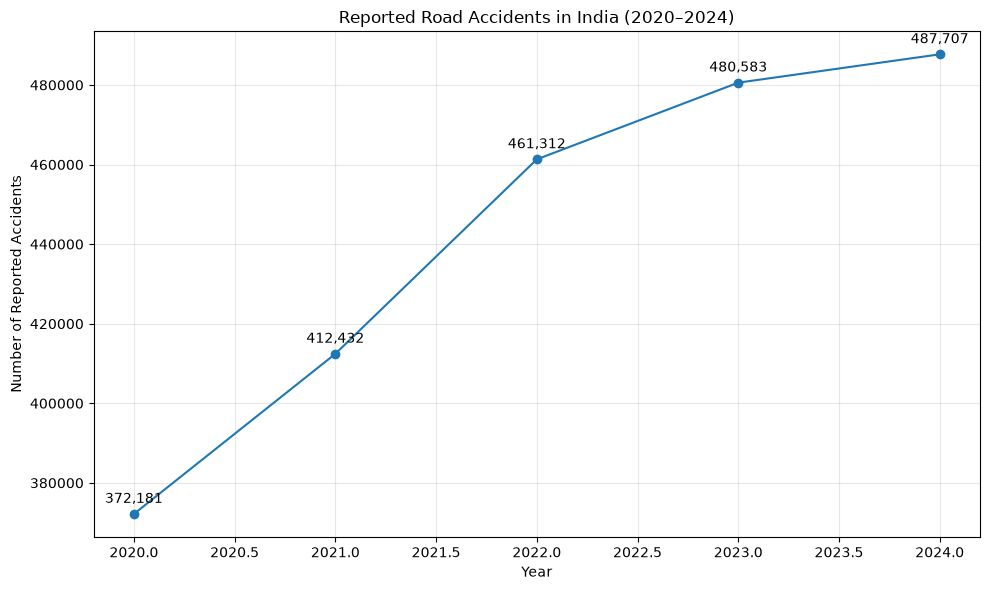

In [35]:
# Convert the yearly totals into a DataFrame
national_accidents_df = national_accidents.reset_index()

national_accidents_df.columns = [
    "year",
    "accidents"
]

# Convert "2020_accidents" → 2020
national_accidents_df["year"] = (
    national_accidents_df["year"]
    .str.replace("_accidents", "", regex=False)
    .astype(int)
)

# Sort by year to guarantee chronological order
national_accidents_df = national_accidents_df.sort_values("year")

# Display the final table used for visualization
display(national_accidents_df)

# Create the line chart
plt.figure(figsize=(10, 6))

plt.plot(
    national_accidents_df["year"],
    national_accidents_df["accidents"],
    marker="o"
)

plt.title("Reported Road Accidents in India (2020–2024)")
plt.xlabel("Year")
plt.ylabel("Number of Reported Accidents")

# Display accident values on the chart
for x, y in zip(
    national_accidents_df["year"],
    national_accidents_df["accidents"]
):
    plt.annotate(
        f"{y:,.0f}",
        (x, y),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center"
    )

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [36]:
# RoadSafe India — State-wise Accident Ranking for 2024

# Select State and 2024 accident counts
state_2024 = state_df[
    ["state", "2024_accidents"]
].copy()

# Sort from highest to lowest
state_2024 = state_2024.sort_values(
    "2024_accidents",
    ascending=False
)

# Display the top 10 States/UTs
top_10_states = state_2024.head(10)

print("Top 10 States/UTs by reported road accidents in 2024:")
display(top_10_states)

Top 10 States/UTs by reported road accidents in 2024:


,state,2024_accidents
22,Tamil Nadu,67526.0
12,Madhya Pradesh,56669.0
11,Kerala,48834.0
26,Uttar Pradesh,46052.0
10,Karnataka,43062.0
13,Maharashtra,36118.0
23,Telangana,25986.0
20,Rajasthan,24838.0
0,Andhra Pradesh,19557.0
6,Gujarat,15588.0


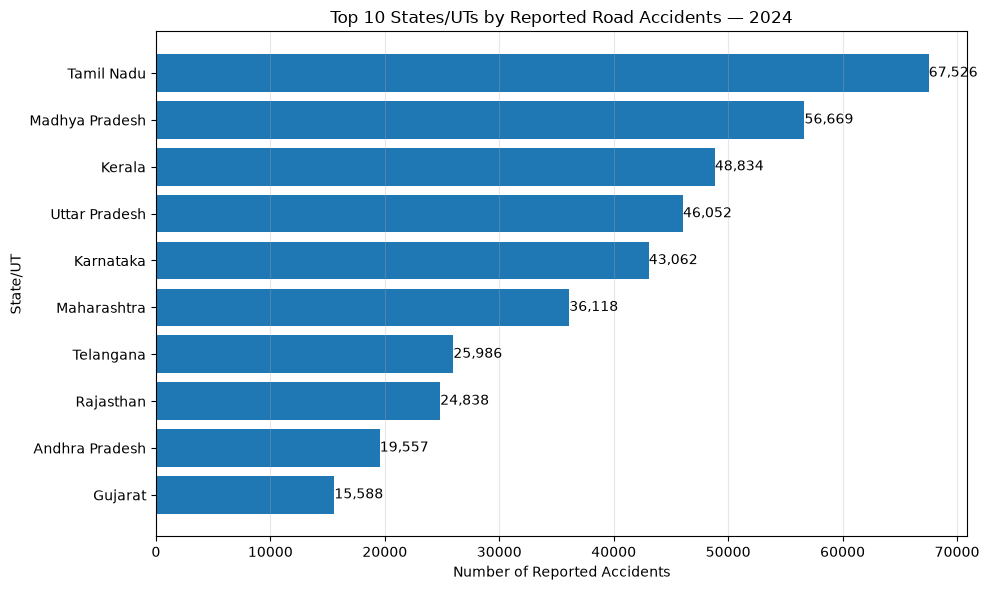

In [37]:
plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_10_states["state"][::-1],
    top_10_states["2024_accidents"][::-1]
)

plt.title("Top 10 States/UTs by Reported Road Accidents — 2024")
plt.xlabel("Number of Reported Accidents")
plt.ylabel("State/UT")

for bar in bars:
    value = bar.get_width()

    plt.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,.0f}",
        va="center",
        ha="left"
    )

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## Insight — State-wise Accident Concentration

Tamil Nadu recorded the highest number of reported road accidents among the
States/UTs in the 2024 dataset, with 67,526 accidents, followed by Madhya
Pradesh with 56,669.

The ten States/UTs with the highest reported accident counts account for a
substantial proportion of the national total. However, raw accident counts
alone should not be interpreted as a direct measure of accident risk.

Differences in population, vehicle ownership, road length, traffic exposure
and other contextual factors can influence the number of accidents observed
in a state.

Further analysis using normalized measures is therefore required before
comparing the underlying risk across States/UTs.